  OFDM 16-QAM Transceiver — System Parameters
  Total Subcarriers       : 64
  Cyclic Prefix Length    : 16 samples
  Pilot Subcarriers       : 8
  Modulation              : 16-QAM (4 bits/symbol)
  Payload bits per OFDM  : 224
  Channel taps            : 3

  Pilot carrier indices   : [ 0  8 16 24 32 40 48 56]
  Data carrier count      : 56

  Single TX @ 25dB SNR:
  Bit errors: 4 / 224
  BER       : 0.017857

  Running BER vs SNR simulation...
    SNR =  -2 dB  →  BER = 0.422589
    SNR =   0 dB  →  BER = 0.394643
    SNR =   2 dB  →  BER = 0.361830
    SNR =   4 dB  →  BER = 0.320893
    SNR =   6 dB  →  BER = 0.281295
    SNR =   8 dB  →  BER = 0.236741
    SNR =  10 dB  →  BER = 0.186875
    SNR =  12 dB  →  BER = 0.145670
    SNR =  14 dB  →  BER = 0.103348
    SNR =  16 dB  →  BER = 0.071786
    SNR =  18 dB  →  BER = 0.048438
    SNR =  20 dB  →  BER = 0.028705
    SNR =  22 dB  →  BER = 0.015804
    SNR =  24 dB  →  BER = 0.008616


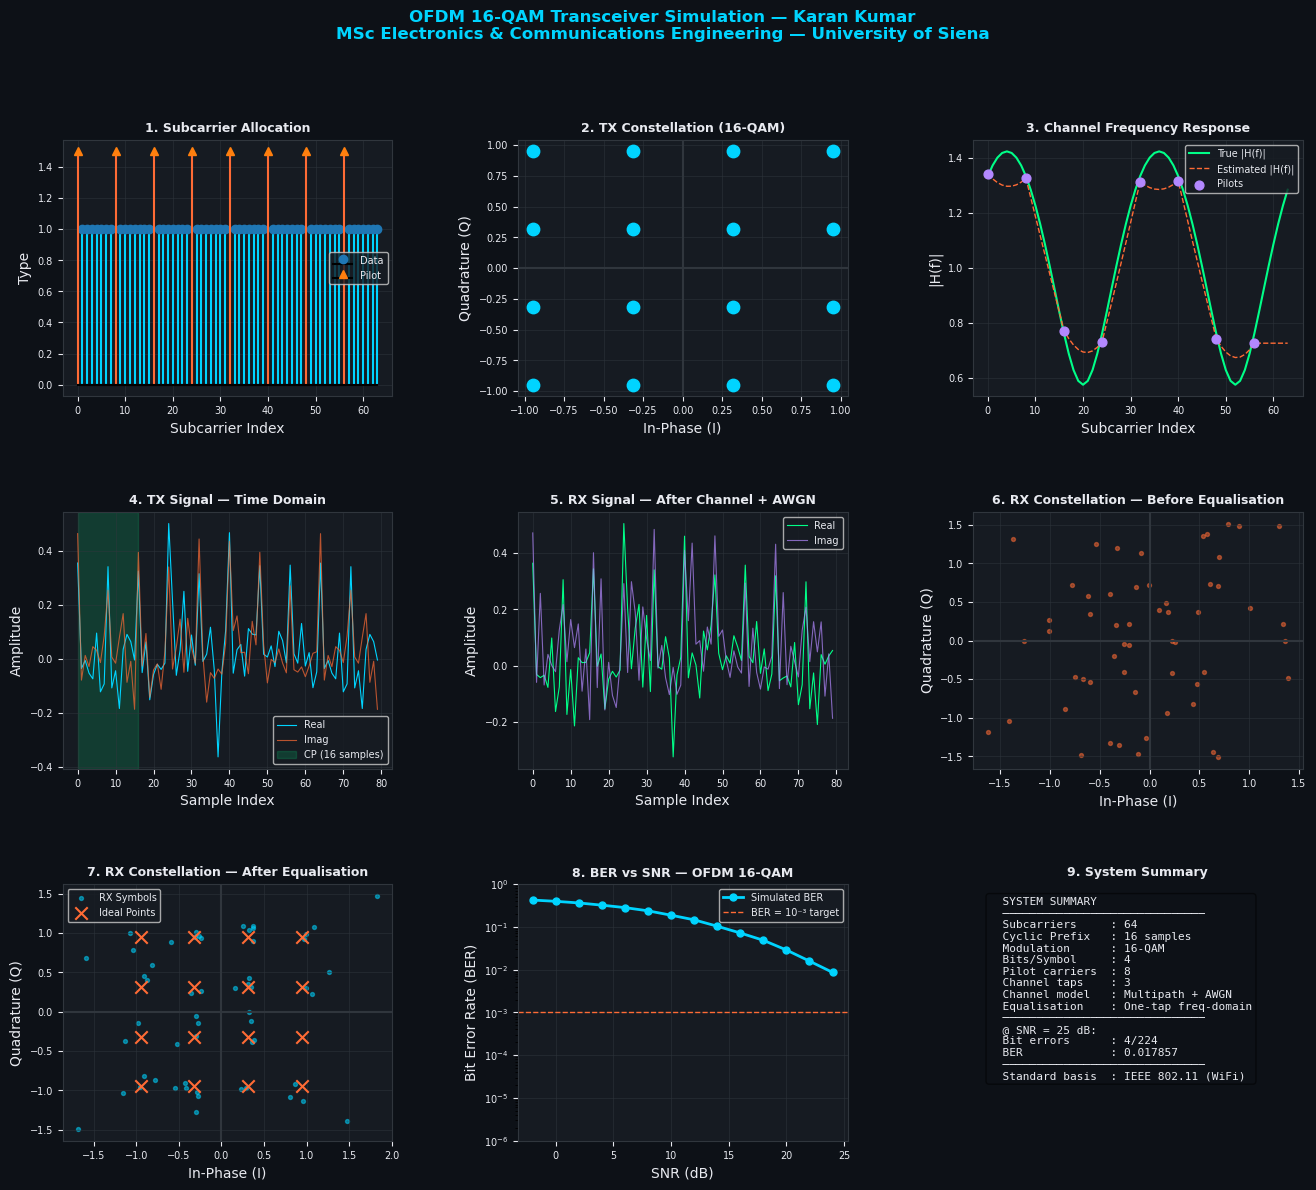


✅ Project 1 complete! Saved: Project1_OFDM_16QAM_Results.png


In [1]:
# ================================================================
# PROJECT 1: OFDM Transceiver with 16-QAM Modulation
# Author      : Karan Kumar
# Tools       : Python, NumPy, SciPy, Matplotlib
# Description : Complete OFDM physical layer simulation including
#               16-QAM Gray-coded modulation, IFFT/FFT multicarrier
#               transmission, cyclic prefix, multipath fading channel,
#               one-tap frequency-domain equalisation, and BER vs SNR.
# Relevance   : Digital Transmission, High-Frequency Systems,
#               Information Theory — MSc Electronics & Communications,
#               University of Siena, Italy
# ================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ================================================================
# STEP 1 — SYSTEM PARAMETERS
# ================================================================
K           = 64          # Total OFDM subcarriers
CP          = K // 4      # Cyclic prefix length (25% of block = 16)
P           = 8           # Number of pilot subcarriers
pilot_val   = 3 + 3j      # Known pilot symbol value
mu          = 4           # Bits per QAM symbol (16-QAM = 2^4)
payload_bits_per_OFDM = (K - P) * mu   # Data bits per OFDM symbol

# Multipath channel impulse response (3-tap)
channel_response = np.array([1, 0, 0.3 + 0.3j])

# SNR range for BER curve
SNR_range_dB = np.arange(-2, 26, 2)

print("=" * 55)
print("  OFDM 16-QAM Transceiver — System Parameters")
print("=" * 55)
print(f"  Total Subcarriers       : {K}")
print(f"  Cyclic Prefix Length    : {CP} samples")
print(f"  Pilot Subcarriers       : {P}")
print(f"  Modulation              : 16-QAM ({mu} bits/symbol)")
print(f"  Payload bits per OFDM  : {payload_bits_per_OFDM}")
print(f"  Channel taps            : {len(channel_response)}")
print("=" * 55)

# ================================================================
# STEP 2 — 16-QAM CONSTELLATION (Gray-coded mapping)
# ================================================================
# Build Gray-coded 16-QAM mapping table
# Maps 4-bit groups → complex QAM symbols
def build_qam16_mapping():
    mapping = {}
    constellation = [-3, -1, 1, 3]
    idx = 0
    for i, real in enumerate(constellation):
        for j, imag in enumerate(constellation):
            gray_i = i ^ (i >> 1)
            gray_j = j ^ (j >> 1)
            bits = (gray_i << 2) | gray_j
            mapping[bits] = (real + 1j * imag) / np.sqrt(10)  # Normalise power
    return mapping

mapping_table = build_qam16_mapping()
demapping_table = {v: k for k, v in mapping_table.items()}

def modulate_qam16(bits):
    """Convert bit stream → 16-QAM symbols"""
    bits = bits[:len(bits) - len(bits) % mu]
    groups = bits.reshape(-1, mu)
    indices = groups.dot(1 << np.arange(mu)[::-1])
    return np.array([mapping_table[i] for i in indices])

def demodulate_qam16(symbols):
    """Hard-decision 16-QAM demapping"""
    bits = []
    constellation = np.array(list(mapping_table.values()))
    for sym in symbols:
        distances = np.abs(sym - constellation)
        closest = constellation[np.argmin(distances)]
        bits.extend([int(b) for b in format(demapping_table[closest], f'0{mu}b')])
    return np.array(bits)

# ================================================================
# STEP 3 — PILOT SUBCARRIER ALLOCATION
# ================================================================
allCarriers = np.arange(K)
pilotCarriers = allCarriers[::K // P]           # Evenly spaced pilots
dataCarriers  = np.delete(allCarriers, pilotCarriers)

print(f"\n  Pilot carrier indices   : {pilotCarriers}")
print(f"  Data carrier count      : {len(dataCarriers)}")

# ================================================================
# STEP 4 — OFDM SYMBOL BUILDER
# ================================================================
def create_ofdm_symbol(data_symbols):
    """Map data + pilots onto subcarriers → IFFT → add CP"""
    OFDM_data = np.zeros(K, dtype=complex)
    OFDM_data[pilotCarriers] = pilot_val
    OFDM_data[dataCarriers]  = data_symbols

    # IFFT: frequency domain → time domain
    OFDM_time = np.fft.ifft(OFDM_data)

    # Add cyclic prefix
    CP_block = OFDM_time[-CP:]
    OFDM_withCP = np.hstack([CP_block, OFDM_time])
    return OFDM_withCP, OFDM_data

# ================================================================
# STEP 5 — CHANNEL MODEL (Multipath + AWGN)
# ================================================================
def apply_channel(signal, snr_db):
    """Multipath convolution + AWGN noise"""
    # Multipath fading via convolution
    convolved = np.convolve(signal, channel_response)[:len(signal)]

    # AWGN noise
    signal_power = np.mean(np.abs(convolved) ** 2)
    noise_power  = signal_power / (10 ** (snr_db / 10))
    noise        = np.sqrt(noise_power / 2) * (
        np.random.randn(len(convolved)) + 1j * np.random.randn(len(convolved))
    )
    return convolved + noise

# ================================================================
# STEP 6 — OFDM RECEIVER
# ================================================================
def receive_ofdm(received_signal):
    """Remove CP → FFT → channel estimation → equalisation"""
    # Remove cyclic prefix
    without_CP = received_signal[CP:]

    # FFT: time domain → frequency domain
    OFDM_rx = np.fft.fft(without_CP)

    # Channel estimation using pilots
    pilots_rx = OFDM_rx[pilotCarriers]
    H_pilots  = pilots_rx / pilot_val

    # Interpolate channel across all subcarriers
    H_est = np.interp(
        allCarriers,
        pilotCarriers,
        H_pilots.real
    ) + 1j * np.interp(
        allCarriers,
        pilotCarriers,
        H_pilots.imag
    )

    # One-tap frequency-domain equalisation
    OFDM_eq = OFDM_rx / H_est

    return OFDM_eq[dataCarriers], H_est, OFDM_rx

# ================================================================
# STEP 7 — SINGLE TRANSMISSION (for visualisation)
# ================================================================
np.random.seed(42)
bits_tx = np.random.randint(0, 2, payload_bits_per_OFDM)
qam_symbols = modulate_qam16(bits_tx)
OFDM_tx, OFDM_grid = create_ofdm_symbol(qam_symbols)

# Apply channel at SNR = 25 dB (for clean visualisation)
SNR_vis = 25
rx_signal = apply_channel(OFDM_tx, SNR_vis)

# Receive and equalise
rx_symbols, H_est, OFDM_rx_raw = receive_ofdm(rx_signal)
bits_rx = demodulate_qam16(rx_symbols)

# Count errors
n_errors = np.sum(bits_tx != bits_rx[:len(bits_tx)])
BER_single = n_errors / len(bits_tx)
print(f"\n  Single TX @ {SNR_vis}dB SNR:")
print(f"  Bit errors: {n_errors} / {len(bits_tx)}")
print(f"  BER       : {BER_single:.6f}")

# ================================================================
# STEP 8 — BER vs SNR CURVE (Monte Carlo)
# ================================================================
print("\n  Running BER vs SNR simulation...")
BER_results = []
N_symbols   = 100  # OFDM symbols per SNR point

for snr in SNR_range_dB:
    total_bits = 0
    total_errors = 0
    for _ in range(N_symbols):
        b_tx   = np.random.randint(0, 2, payload_bits_per_OFDM)
        syms   = modulate_qam16(b_tx)
        tx_sig, _ = create_ofdm_symbol(syms)
        rx_sig = apply_channel(tx_sig, snr)
        rx_sym, _, _ = receive_ofdm(rx_sig)
        b_rx   = demodulate_qam16(rx_sym)
        errs   = np.sum(b_tx != b_rx[:len(b_tx)])
        total_bits   += len(b_tx)
        total_errors += errs
    ber = total_errors / total_bits
    BER_results.append(max(ber, 1e-6))
    print(f"    SNR = {snr:3d} dB  →  BER = {ber:.6f}")

# ================================================================
# STEP 9 — CHANNEL FREQUENCY RESPONSE
# ================================================================
H_exact = np.fft.fft(channel_response, K)

# ================================================================
# STEP 10 — PLOTTING (3x3 Grid)
# ================================================================
fig = plt.figure(figsize=(16, 13))
fig.patch.set_facecolor('#0D1117')
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)

ACCENT = '#00D4FF'
GREEN  = '#00FF88'
ORANGE = '#FF6B35'
PURPLE = '#B388FF'
WHITE  = '#E8EAF0'
PANEL  = '#161B22'

def style_ax(ax, title):
    ax.set_facecolor(PANEL)
    ax.set_title(title, color=WHITE, fontsize=9, fontweight='bold', pad=6)
    ax.tick_params(colors=WHITE, labelsize=7)
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363D')
    ax.xaxis.label.set_color(WHITE)
    ax.yaxis.label.set_color(WHITE)
    ax.grid(True, color='#30363D', linewidth=0.5, alpha=0.7)

fig.suptitle('OFDM 16-QAM Transceiver Simulation — Karan Kumar\n'
             'MSc Electronics & Communications Engineering — University of Siena',
             color=ACCENT, fontsize=12, fontweight='bold', y=0.98)

# Plot 1: Subcarrier allocation
ax1 = fig.add_subplot(gs[0, 0])
style_ax(ax1, '1. Subcarrier Allocation')
ax1.stem(dataCarriers,  np.ones(len(dataCarriers)),
         linefmt=ACCENT, markerfmt=f'C0o', basefmt='k-', label='Data')
ax1.stem(pilotCarriers, 1.5*np.ones(len(pilotCarriers)),
         linefmt=ORANGE, markerfmt=f'C1^', basefmt='k-', label='Pilot')
ax1.set_xlabel('Subcarrier Index'); ax1.set_ylabel('Type')
ax1.legend(fontsize=7, facecolor=PANEL, labelcolor=WHITE)

# Plot 2: TX constellation
ax2 = fig.add_subplot(gs[0, 1])
style_ax(ax2, '2. TX Constellation (16-QAM)')
pts = np.array(list(mapping_table.values()))
ax2.scatter(pts.real, pts.imag, c=ACCENT, s=80, zorder=5)
ax2.scatter(qam_symbols.real, qam_symbols.imag, c=ORANGE, s=10, alpha=0.4)
ax2.set_xlabel('In-Phase (I)'); ax2.set_ylabel('Quadrature (Q)')
ax2.axhline(0, color='#30363D'); ax2.axvline(0, color='#30363D')

# Plot 3: Channel frequency response
ax3 = fig.add_subplot(gs[0, 2])
style_ax(ax3, '3. Channel Frequency Response')
ax3.plot(allCarriers, np.abs(H_exact),  color=GREEN,  lw=1.5, label='True |H(f)|')
ax3.plot(allCarriers, np.abs(H_est),    color=ORANGE, lw=1,
         ls='--', label='Estimated |H(f)|')
ax3.scatter(pilotCarriers, np.abs(H_est[pilotCarriers]),
            c=PURPLE, s=40, zorder=5, label='Pilots')
ax3.set_xlabel('Subcarrier Index'); ax3.set_ylabel('|H(f)|')
ax3.legend(fontsize=7, facecolor=PANEL, labelcolor=WHITE)

# Plot 4: Time domain TX signal
ax4 = fig.add_subplot(gs[1, 0])
style_ax(ax4, '4. TX Signal — Time Domain')
ax4.plot(np.real(OFDM_tx), color=ACCENT, lw=0.8, label='Real')
ax4.plot(np.imag(OFDM_tx), color=ORANGE, lw=0.8, alpha=0.7, label='Imag')
ax4.axvspan(0, CP, alpha=0.15, color=GREEN, label=f'CP ({CP} samples)')
ax4.set_xlabel('Sample Index'); ax4.set_ylabel('Amplitude')
ax4.legend(fontsize=7, facecolor=PANEL, labelcolor=WHITE)

# Plot 5: RX signal after channel
ax5 = fig.add_subplot(gs[1, 1])
style_ax(ax5, '5. RX Signal — After Channel + AWGN')
ax5.plot(np.real(rx_signal), color=GREEN,  lw=0.8, label='Real')
ax5.plot(np.imag(rx_signal), color=PURPLE, lw=0.8, alpha=0.7, label='Imag')
ax5.set_xlabel('Sample Index'); ax5.set_ylabel('Amplitude')
ax5.legend(fontsize=7, facecolor=PANEL, labelcolor=WHITE)

# Plot 6: RX constellation (before equalisation)
ax6 = fig.add_subplot(gs[1, 2])
style_ax(ax6, '6. RX Constellation — Before Equalisation')
rx_data_raw = OFDM_rx_raw[dataCarriers]
ax6.scatter(rx_data_raw.real, rx_data_raw.imag,
            c=ORANGE, s=8, alpha=0.5)
ax6.set_xlabel('In-Phase (I)'); ax6.set_ylabel('Quadrature (Q)')
ax6.axhline(0, color='#30363D'); ax6.axvline(0, color='#30363D')

# Plot 7: RX constellation (after equalisation)
ax7 = fig.add_subplot(gs[2, 0])
style_ax(ax7, '7. RX Constellation — After Equalisation')
ax7.scatter(rx_symbols.real, rx_symbols.imag,
            c=ACCENT, s=8, alpha=0.5, label='RX Symbols')
ax7.scatter(pts.real, pts.imag, c=ORANGE, s=80,
            marker='x', zorder=5, label='Ideal Points')
ax7.set_xlabel('In-Phase (I)'); ax7.set_ylabel('Quadrature (Q)')
ax7.axhline(0, color='#30363D'); ax7.axvline(0, color='#30363D')
ax7.legend(fontsize=7, facecolor=PANEL, labelcolor=WHITE)

# Plot 8: BER vs SNR
ax8 = fig.add_subplot(gs[2, 1])
style_ax(ax8, '8. BER vs SNR — OFDM 16-QAM')
ax8.semilogy(SNR_range_dB, BER_results,
             color=ACCENT, lw=2, marker='o', ms=5, label='Simulated BER')
ax8.axhline(y=1e-3, color=ORANGE, ls='--', lw=1, label='BER = 10⁻³ target')
ax8.set_xlabel('SNR (dB)'); ax8.set_ylabel('Bit Error Rate (BER)')
ax8.legend(fontsize=7, facecolor=PANEL, labelcolor=WHITE)
ax8.set_ylim([1e-6, 1])

# Plot 9: Summary stats
ax9 = fig.add_subplot(gs[2, 2])
ax9.set_facecolor(PANEL)
for spine in ax9.spines.values():
    spine.set_edgecolor('#30363D')
ax9.axis('off')
summary = (
    f"  SYSTEM SUMMARY\n"
    f"  {'─'*30}\n"
    f"  Subcarriers     : {K}\n"
    f"  Cyclic Prefix   : {CP} samples\n"
    f"  Modulation      : 16-QAM\n"
    f"  Bits/Symbol     : {mu}\n"
    f"  Pilot carriers  : {P}\n"
    f"  Channel taps    : {len(channel_response)}\n"
    f"  Channel model   : Multipath + AWGN\n"
    f"  Equalisation    : One-tap freq-domain\n"
    f"  {'─'*30}\n"
    f"  @ SNR = {SNR_vis} dB:\n"
    f"  Bit errors      : {n_errors}/{len(bits_tx)}\n"
    f"  BER             : {BER_single:.6f}\n"
    f"  {'─'*30}\n"
    f"  Standard basis  : IEEE 802.11 (WiFi)"
)
ax9.text(0.05, 0.95, summary, transform=ax9.transAxes,
         fontsize=8, verticalalignment='top',
         fontfamily='monospace', color=WHITE,
         bbox=dict(boxstyle='round', facecolor='#0D1117', alpha=0.5))
ax9.set_title('9. System Summary', color=WHITE,
              fontsize=9, fontweight='bold', pad=6)

plt.savefig('Project1_OFDM_16QAM_Results.png', dpi=150,
            bbox_inches='tight', facecolor='#0D1117')
plt.show()
print("\n✅ Project 1 complete! Saved: Project1_OFDM_16QAM_Results.png")